# 5. Random Forest

This notebook trains a **Random Forest** classifier (500 trees) and performs **SHAP** interpretability analysis to understand feature contributions.

> **Colab Setup** — La cella seguente configura automaticamente l'ambiente Google Colab. Se stai eseguendo il notebook in locale, verrà saltata automaticamente.

In [ ]:
# ── Colab Setup ──────────────────────────────────────────────
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('ecommerce-intention'):
        !git clone -q https://github.com/davidemeta/Predicting-Online-Shoppers-Purchasing-Intention.git ecommerce-intention
    os.chdir('ecommerce-intention/notebooks')
    !pip install -q -r ../requirements.txt

    # Riesegui preprocessing se i dati non esistono ancora
    if not os.path.exists('../data/preprocessed_data.npz'):
        sys.path.insert(0, str(os.path.abspath('..')))
        from src.preprocessing import load_data, encode_features, split_and_scale, apply_smote
        import numpy as np
        from pathlib import Path

        df = load_data(Path('../data/online_shoppers_intention.csv'))
        df = encode_features(df)
        X = df.drop('Revenue', axis=1)
        y = df['Revenue']
        X_train, X_test, y_train, y_test, scaler, feature_names = split_and_scale(X, y)
        X_train_res, y_train_res = apply_smote(X_train, y_train)

        np.savez('../data/preprocessed_data.npz',
                 X_train=X_train_res, X_test=X_test,
                 y_train=y_train_res, y_test=y_test)
        np.save('../data/feature_names.npy', np.array(feature_names))
        print('Preprocessing completato')

    print('Colab setup completato')

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle

sns.set_style('whitegrid')

In [2]:
# Load preprocessed data
data = np.load('../data/preprocessed_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (16676, 17)
Test set:     (2466, 17)


In [3]:
from src.models import train_random_forest
from src.evaluation import compute_metrics, plot_confusion_matrix, plot_roc_curve, shap_analysis

## 5.1 Model Training

In [4]:
rf_model = train_random_forest(X_train, y_train)

print('Random Forest Parameters:')
print(f'  n_estimators:  {rf_model.n_estimators}')
print(f'  class_weight:  {rf_model.class_weight}')
print(f'  random_state:  {rf_model.random_state}')
print(f'  n_features:    {rf_model.n_features_in_}')
print(f'  n_jobs:        {rf_model.n_jobs}')

Random Forest Parameters:
  n_estimators:  500
  class_weight:  balanced
  random_state:  42
  n_features:    17
  n_jobs:        -1


## 5.2 Gini Feature Importance

The default `feature_importances_` in scikit-learn uses **Mean Decrease in Impurity (Gini)**. While useful for a quick overview, it has known biases (see Section 5.4 for SHAP comparison).

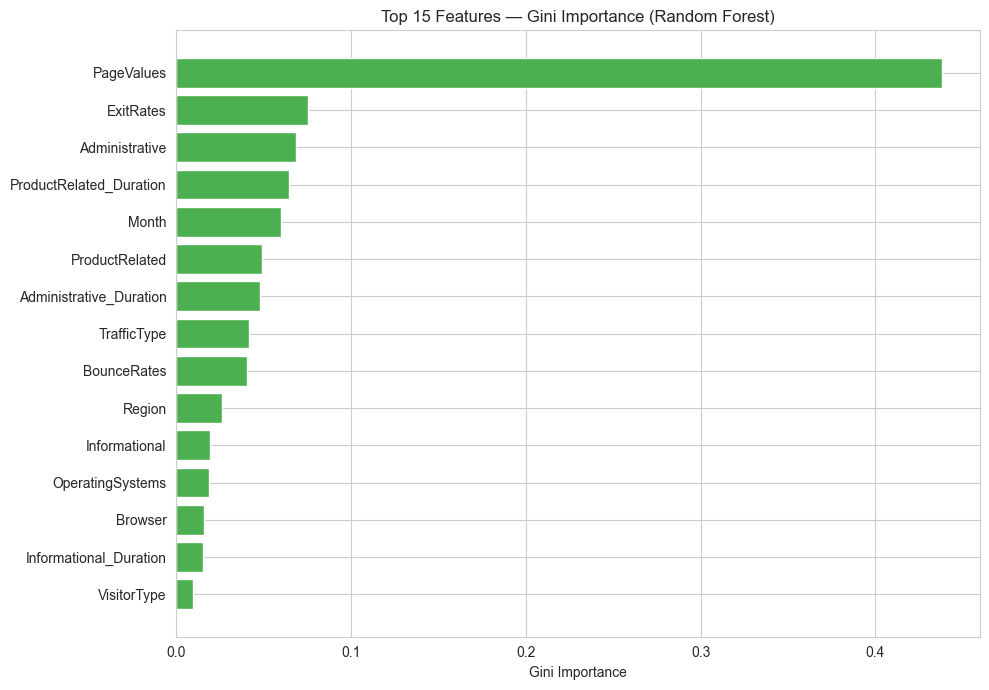


Note: Gini importance is biased toward high-cardinality features.
   See Section 5.4 for SHAP-based feature ranking.


In [5]:
gini_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': rf_model.feature_importances_
}).sort_values('Gini Importance', ascending=True)

# Plot top 15
top_n = 15
top_gini = gini_df.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_gini['Feature'], top_gini['Gini Importance'],
        color='#4CAF50', edgecolor='white')
ax.set_xlabel('Gini Importance')
ax.set_title(f'Top {top_n} Features — Gini Importance (Random Forest)')
plt.tight_layout()
plt.show()

print('\nNote: Gini importance is biased toward high-cardinality features.')
print('   See Section 5.4 for SHAP-based feature ranking.')

## 5.3 Evaluation

In [6]:
rf_results = compute_metrics(rf_model, X_test, y_test, 'Random Forest')

print(f"Accuracy:  {rf_results['accuracy']:.4f}")
print(f"Precision: {rf_results['precision']:.4f}")
print(f"Recall:    {rf_results['recall']:.4f}")
print(f"F1-Score:  {rf_results['f1']:.4f}")
print(f"ROC-AUC:   {rf_results['roc_auc']:.4f}")
print(f"\nClassification Report:\n{rf_results['report']}")

Accuracy:  0.8897
Precision: 0.6297
Recall:    0.6990
F1-Score:  0.6625
ROC-AUC:   0.9217

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2084
           1       0.63      0.70      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.81      0.80      2466
weighted avg       0.90      0.89      0.89      2466



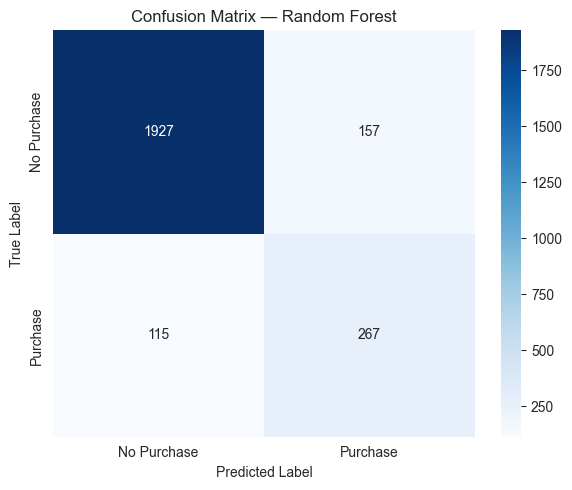

In [7]:
plot_confusion_matrix(y_test, rf_results['y_pred'], 'Random Forest')

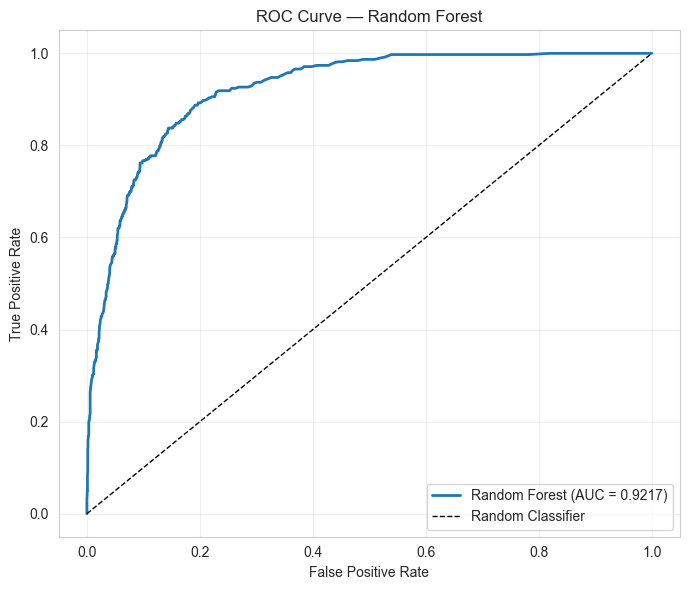

In [8]:
plot_roc_curve(y_test, rf_results['y_proba'], 'Random Forest')

## 5.4 SHAP Interpretability

**SHAP** (SHapley Additive exPlanations) provides theoretically grounded feature attributions:

- **Summary plot**: Shows the distribution of SHAP values for each feature across all test samples. Color indicates feature value (red = high, blue = low).
- **Bar plot**: Shows mean |SHAP value| — the average impact of each feature on predictions.

Unlike Gini importance, SHAP shows both **magnitude** and **direction** of feature effects.

In [ ]:
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams['figure.autolayout'] = True 

shap_values = shap_analysis(rf_model, X_test, feature_names, save_dir='../report/Resources')

## 5.5 Summary

In [10]:
# Save model and results
save_dir = Path('../data')
joblib.dump(rf_model, save_dir / 'rf_model.joblib')

rf_results_save = {
    'model_name': rf_results['model_name'],
    'y_pred': rf_results['y_pred'],
    'y_proba': rf_results['y_proba'],
    'accuracy': rf_results['accuracy'],
    'precision': rf_results['precision'],
    'recall': rf_results['recall'],
    'f1': rf_results['f1'],
    'roc_auc': rf_results['roc_auc'],
}
with open(save_dir / 'rf_results.pkl', 'wb') as f:
    pickle.dump(rf_results_save, f)

print('Model and results saved.')

Model and results saved.
